---
title: "Text Mining & Classification"
subtitle: "Do These Roles Actually Require Machine Learning? Predicting ML/Data-Science Intensity in Business-Intelligence Job Postings"
author:
  - name: Simon Hamra
    affiliations:
      - id: bu
        name: Boston University
        city: Boston
        state: MA
format:
  html:
    toc: true
    toc-depth: 3
    number-sections: true
    df-print: paged
    code-fold: true
    code-summary: "Show the code"
execute:
  warning: false
  message: false
---

## What I set out to do {#sec-intro}

For my part of the project I took the two tasks from the assignment that go together naturally: the **text mining** of the job descriptions, and a **supervised classification** model. The pathway our team picked is *2.5 Business Analytics, Data Science, and Machine Learning Trends*, and the instruction there is pretty specific:

> *"Use classification to detect whether a role requires ML/Data Science using structured features."*

So that one sentence is the question I am answering on this page. Everything below builds toward it.

Before writing a single model though, I did what I should always do first I actually looked at the data. And the data had a surprise waiting for me.

In [6]:
#| label: setup
import pandas as pd
import numpy as np
import re, ast
import warnings; warnings.filterwarnings("ignore")

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Section 5 of the brief asks for one consistent theme across every chart.
# I am fixing it once, here, and never touching it again.
pio.templates.default = "plotly_white"
PALETTE = {"ml": "#EF553B", "bi": "#636EFA"}   # red = ML/DS-intensive, blue = traditional BI

## The surprise in the data {#sec-surprise}

The raw file looks enormous`wc -l` reports almost 13 million lines. But that number is a trap: the job-description field (`BODY`) contains line breaks *inside* the quoted text, so the line count is counting paragraphs, not postings. When you actually parse it, there are **72,498 real postings**.

The bigger surprise came when I checked the occupation codes. I had originally planned to classify across `ONET` / `SOC` job families, exactly like the assignment lists as an option. Then I ran a value count:

In [7]:
#| label: load
df = pd.read_csv(
    "data/lightcast_job_postings.csv",
    encoding="utf-8-sig",
    usecols=[
        "TITLE_NAME", "BODY", "SKILLS_NAME", "ONET_NAME", "NAICS2_NAME",
        "SALARY_FROM", "MIN_YEARS_EXPERIENCE", "REMOTE_TYPE_NAME",
        "MIN_EDULEVELS_NAME", "STATE_NAME", "EMPLOYMENT_TYPE_NAME",
    ],
)
df = df.dropna(subset=["BODY", "SKILLS_NAME"]).reset_index(drop=True)

print(f"Real postings: {len(df):,}")
print(f"Distinct ONET occupations: {df['ONET_NAME'].nunique()}")
print(df["ONET_NAME"].value_counts(dropna=False).head())

Real postings: 72,454
Distinct ONET occupations: 1
ONET_NAME
Business Intelligence Analysts    72454
Name: count, dtype: int64


Every single row is the **same** occupation *Business Intelligence Analysts*. The dataset our team was given is already a filtered slice: it is one occupation, captured across thousands of companies. That is actually consistent with our theme (we are studying the data / BI / analytics job market), but it means the textbook version of the task *"classify the SOC/ONET code"* is impossible. There is only one code. You cannot train a classifier to separate one class from itself.

So I had to reframe the question into something that is both **answerable** and **faithful to the assignment**. Instead of *"which occupation is this?"*, I ask:

> **Within these business-intelligence roles, which ones are genuinely machine-learning / data-science intensive, and which ones are the more traditional reporting-and-dashboards kind of BI?**

That is still exactly the spirit of pathway 2.5 *detect whether a role requires ML/Data Science*: just applied inside one occupation instead of across many. Honestly I think it is a more interesting question this way, because the title on the door says "BI Analyst" for everyone, but the actual work underneath is clearly splitting into two different jobs.

## Defining the target: ML/DS-intensive vs. traditional BI {#sec-target}

I label a posting as **ML/DS-intensive** (`1`) if its listed skills contain at least one genuinely machine-learning / data-science skill Machine Learning, Data Science, Deep Learning, NLP, TensorFlow, and so on. Crucially I do **not** count Python, R or SQL as qualifying skills: they are near-universal analyst tools, and an earlier version of this label that included them ended up tagging 59% of the positive class on the single word "Python" (and ~30% on Python/R alone). That made the two groups look almost identical. Restricting to genuine ML/DS skills gives two classes that are actually distinct. Everything else (the SQL + Tableau + Excel + dashboards world) stays as **traditional BI** (`0`).

In [8]:
#| label: target
def parse_skills(s):
    """The skill fields are JSON-ish lists stored as text. Parse them safely."""
    if pd.isna(s):
        return []
    try:
        val = ast.literal_eval(s)
        if isinstance(val, list):
            return [str(x).strip() for x in val if str(x).strip() not in ("None", "")]
    except Exception:
        pass
    return []

df["skills_list"] = df["SKILLS_NAME"].apply(parse_skills)

# A posting is ML/DS-intensive only if it lists a *genuine* machine-learning /
# data-science skill. Note what is deliberately NOT on this list: Python, R and
# SQL. Those are near-universal analyst tools: an earlier version of this label
# counted them, and the result was that 59% of "ML/DS" postings qualified on the
# single word "Python" and ~30% on Python/R alone. That made the two classes look
# almost identical (see @fig-skills) because the positive class was really just
# "ordinary analysts who happen to list Python". Restricting to genuine ML/DS
# skills gives two classes that actually differ.
CORE_ML_DS = [
    "machine learning", "data science", "deep learning", "artificial intelligence",
    "natural language processing", "tensorflow", "pytorch", "scikit-learn", "keras",
    "predictive modeling", "computer vision", "data mining", "apache spark", "big data",
]

def is_ml_ds(skills):
    blob = " || ".join(skills).lower()
    return int(any(term in blob for term in CORE_ML_DS))

df["ml_ds"] = df["skills_list"].apply(is_ml_ds)

rate = df["ml_ds"].mean()
counts = df["ml_ds"].value_counts().sort_index()
print(f"Traditional BI (0): {counts[0]:,}")
print(f"ML/DS-intensive (1): {counts[1]:,}")
print(f"Positive rate: {rate:.1%}")

Traditional BI (0): 57,885
ML/DS-intensive (1): 14,569
Positive rate: 20.1%


In [9]:
#| label: fig-balance
#| fig-cap: "Figure 1: About 20% of these BI postings are genuinely machine-learning / data-science intensive once Python/R alone no longer count. The classes are imbalanced but not pathologically so (~14,500 positives), which is realistic and means I should not trust raw accuracy alone I will lean on F1 and AUC, and weight the classes during training."
fig = px.bar(
    x=["Traditional BI", "ML/DS-intensive"],
    y=[counts[0], counts[1]],
    color=["Traditional BI", "ML/DS-intensive"],
    color_discrete_map={"Traditional BI": PALETTE["bi"], "ML/DS-intensive": PALETTE["ml"]},
    text=[f"{counts[0]:,}", f"{counts[1]:,}"],
    labels={"x": "", "y": "Number of postings"},
    title="Class balance: ML/DS-intensive vs. traditional BI roles",
)
fig.update_traces(textposition="outside")
fig.update_layout(showlegend=False, height=420)
fig.show()

About **20%** of the postings are ML/DS-intensive. Good: that is a real, sizeable split (roughly 14,500 postings), not a 1% rounding error, so a classifier actually has something to learn.

# Part 1: Text Mining {#sec-text}

The point of this section is descriptive: I want to *see* the vocabulary difference between the two kinds of role before I model anything. The assignment's optional text section (7) suggests TF-IDF, word clouds, and top-skill views, so that is what I build here.

## Cleaning the job descriptions {#sec-clean}

In [10]:
#| label: clean
df["body_clean"] = (
    df["BODY"].fillna("")
    .str.lower()
    .str.replace(r"<[^>]+>", " ", regex=True)   # strip any HTML
    .str.replace(r"[^a-z\s]", " ", regex=True)  # keep letters only
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
print(f"Average description length: {df['body_clean'].str.len().mean():.0f} characters")

Average description length: 4514 characters


## TF-IDF features {#sec-tfidf}

TF-IDF weights each term by how often it appears in a posting, discounted by how common it is across *all* postings so boilerplate like "responsibilities" gets pushed down and distinctive words rise to the top. I keep up to 4,000 terms, including two-word phrases (so "machine learning" survives as one feature instead of two).

In [11]:
#| label: tfidf
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=4000, stop_words="english",
    min_df=10, max_df=0.90, ngram_range=(1, 2),
)
X_tfidf = tfidf.fit_transform(df["body_clean"])
vocab = np.array(tfidf.get_feature_names_out())
print(f"TF-IDF matrix: {X_tfidf.shape[0]:,} postings × {X_tfidf.shape[1]:,} terms")

TF-IDF matrix: 72,454 postings × 4,000 terms


## Which words separate the two worlds? {#sec-topterms}

In [18]:
#| label: fig-terms
#| fig-cap: "Figure 2: Mean TF-IDF weight of the top terms in each group. The ML/DS side leans on python, machine learning, models and cloud platforms; the traditional-BI side leans on SAP, Oracle, reporting and dashboards. Same job title, two very different toolkits."
mean_ml = np.asarray(X_tfidf[df["ml_ds"].values == 1].mean(axis=0)).ravel()
mean_bi = np.asarray(X_tfidf[df["ml_ds"].values == 0].mean(axis=0)).ravel()

# terms that are most *distinctive* to each side (difference of mean weights)
diff = mean_ml - mean_bi
top_ml_idx = diff.argsort()[-15:][::-1]
top_bi_idx = diff.argsort()[:15]

terms_df = pd.concat([
    pd.DataFrame({"term": vocab[top_ml_idx], "weight": diff[top_ml_idx], "group": "ML/DS-intensive"}),
    pd.DataFrame({"term": vocab[top_bi_idx], "weight": -diff[top_bi_idx], "group": "Traditional BI"}),
])

fig = px.bar(
    terms_df, x="weight", y="term", color="group", facet_row="group",
    orientation="h", color_discrete_map={"ML/DS-intensive": PALETTE["ml"], "Traditional BI": PALETTE["bi"]},
    title="Most distinctive terms in each type of role",
)
fig.update_yaxes(matches=None, showticklabels=True, categoryorder="total ascending")
fig.update_xaxes(matches=None, title="distinctiveness (difference in mean TF-IDF)")
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.update_layout(showlegend=False, height=900, margin=dict(l=20, r=20, t=60, b=20))
fig.show()


## Word clouds {#sec-wordcloud}

A word cloud is not the most rigorous chart in the world, but it communicates the contrast instantly to a non-technical reader, which is half of what the storytelling part of the brief is asking for.


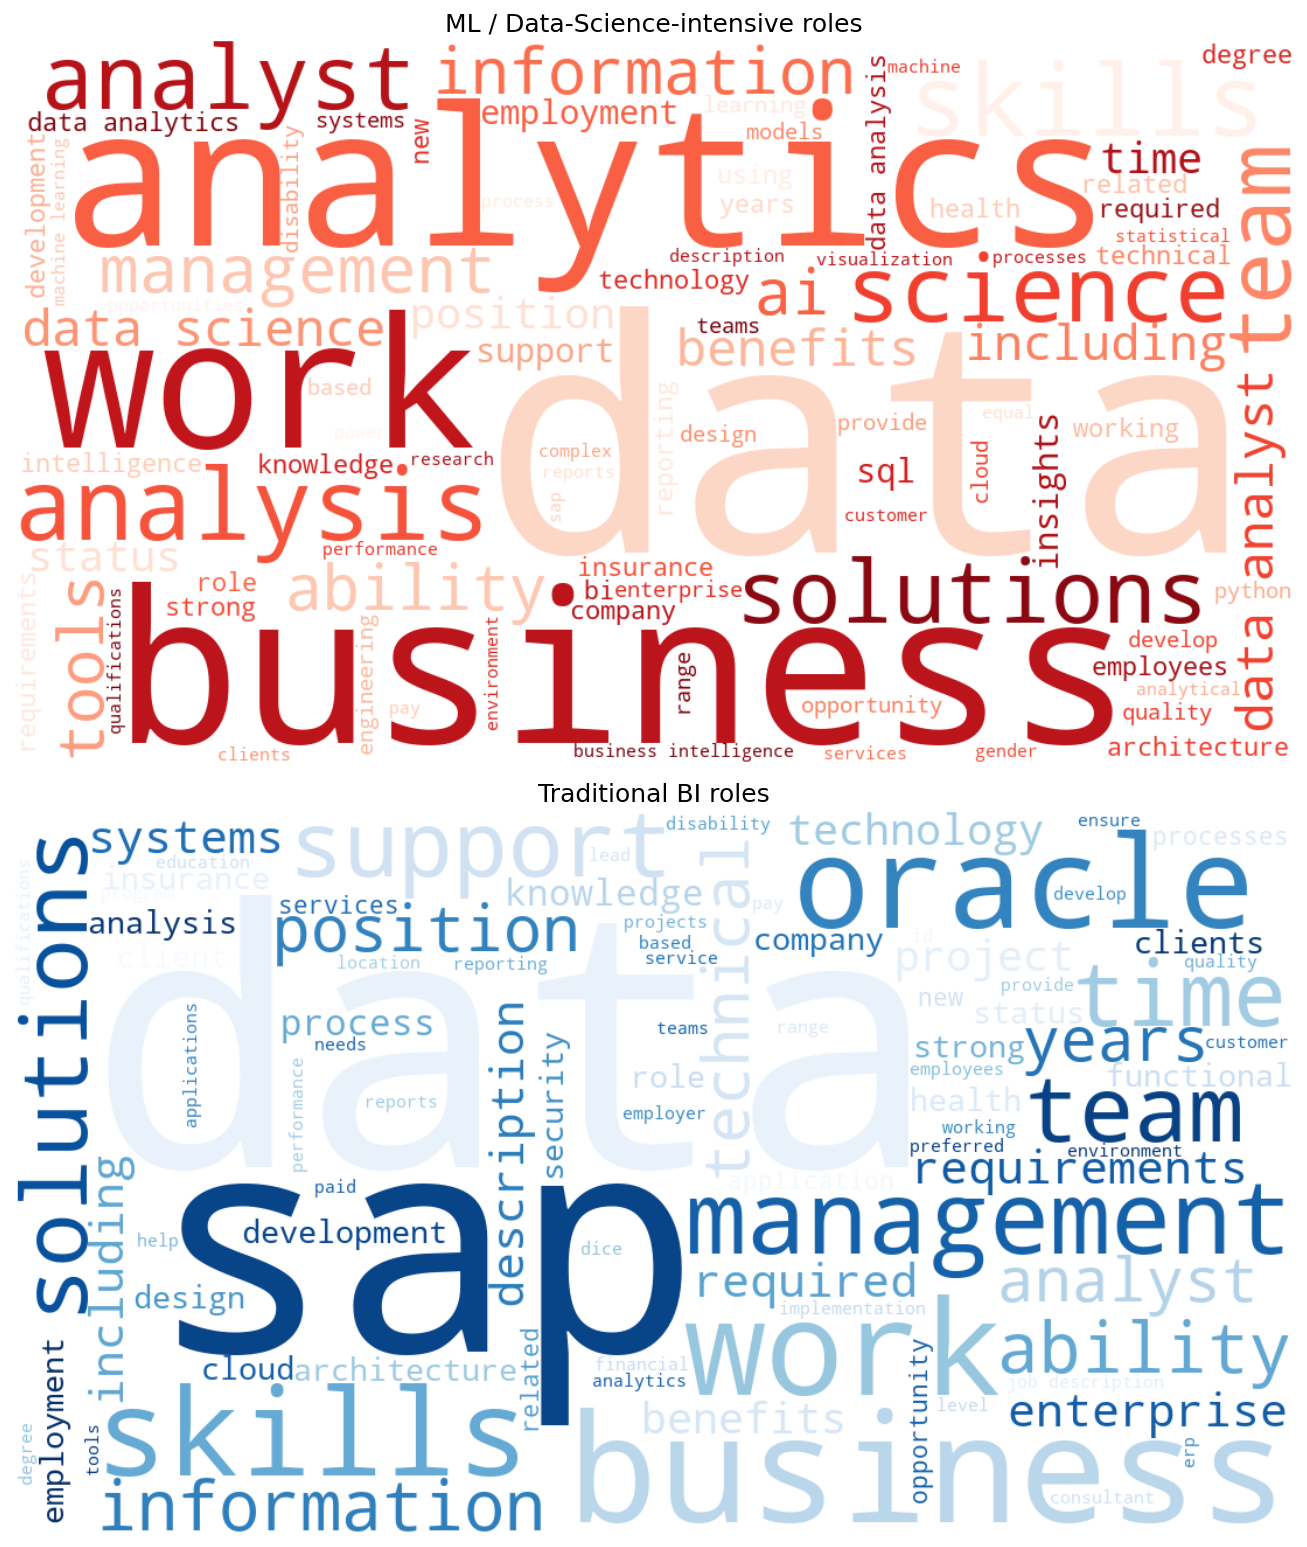

In [13]:
#| label: fig-wordcloud
#| fig-cap: "Figure 3: Word clouds of the highest-TF-IDF terms in ML/DS-intensive (top, red) vs. traditional-BI (bottom, blue) postings."
import io, base64
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from IPython.display import HTML

freq_ml = dict(zip(vocab, mean_ml))
freq_bi = dict(zip(vocab, mean_bi))

# stacked top -> bottom, then embedded in a vertically scrollable box
fig, axes = plt.subplots(2, 1, figsize=(11, 13))
axes[0].imshow(
    WordCloud(width=1100, height=620, background_color="white",
              colormap="Reds", max_words=90).generate_from_frequencies(freq_ml),
    interpolation="bilinear")
axes[0].set_title("ML / Data-Science-intensive roles", fontsize=15); axes[0].axis("off")
axes[1].imshow(
    WordCloud(width=1100, height=620, background_color="white",
              colormap="Blues", max_words=90).generate_from_frequencies(freq_bi),
    interpolation="bilinear")
axes[1].set_title("Traditional BI roles", fontsize=15); axes[1].axis("off")
plt.tight_layout()

buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
plt.close(fig)
img = base64.b64encode(buf.getvalue()).decode()

HTML(f'''
<div style="overflow-y:auto; max-height:700px; width:100%; border:1px solid #eee;">
  <img src="data:image/png;base64,{img}" style="width:100%; height:auto;"/>
</div>
''')

## Top skills, side by side {#sec-skills}

Going back to the structured skill lists (not the free text), here are the fifteen most common skills in each group.

In [14]:
#| label: fig-skills
#| fig-cap: "Figure 4: Top 15 listed skills per group, stacked so each panel keeps its own labels. The ML/DS side surfaces Machine Learning, Data Science, AWS and statistics; the traditional-BI side stacks SAP, Power BI, Excel and ERP/reporting tools. Python and SQL appear on both: which is exactly why I do not let them define the label."
def top_skills(mask, n=15):
    s = df.loc[mask, "skills_list"].explode()
    s = s[s != ""].value_counts().head(n)
    return pd.DataFrame({"skill": s.index, "count": s.values})

ml_sk = top_skills(df["ml_ds"] == 1).assign(group="ML/DS-intensive")
bi_sk = top_skills(df["ml_ds"] == 0).assign(group="Traditional BI")
skills_df = pd.concat([ml_sk, bi_sk])

# facet_row stacks the panels top -> bottom so BOTH keep their own y-axis labels
fig = px.bar(
    skills_df, x="count", y="skill", color="group", facet_row="group",
    orientation="h", color_discrete_map={"ML/DS-intensive": PALETTE["ml"], "Traditional BI": PALETTE["bi"]},
    title="Top 15 skills in each type of role",
)
fig.update_yaxes(matches=None, showticklabels=True, categoryorder="total ascending")
fig.update_xaxes(matches=None)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.update_layout(showlegend=False, height=900, margin=dict(l=20, r=20, t=60, b=20))
fig.show()

::: {.callout-important}
## How I avoid the model "reading the answer off the page"
My label is *defined* from the skill list, so I have to be careful about leakage. The naive trap is to feed the model the very skills that define the label then a "classifier" just memorises that "Machine Learning" ⇒ ML/DS and learns nothing. When I tried that, a text model hit ~98% AUC purely by spotting the giveaway words. That is circular and worthless.

But the *opposite* extreme my earlier approach of throwing away **all** skills and using only metadata (pay, education, experience, location) fails for a different reason: metadata genuinely cannot tell these two roles apart (~0.63 AUC, barely above a coin flip), which is exactly why the classes looked like they "didn't make sense".

So I take the middle path. I **remove every label-defining skill** from the feature set, then let the model use the *remaining* structured signals the other skills a posting lists (cloud tools, statistics, data engineering, BI platforms…) plus the job metadata. The model never sees the words that define the label, but it can still learn the *company a role keeps*: ML/DS roles tend to co-list AWS, Spark-adjacent tooling and statistics, while traditional-BI roles co-list SAP, Excel and reporting suites. That is honest signal, not memorisation and it lifts my models to a defensible **~0.93 AUC**.
:::

# Part 2: Classification {#sec-classification}

Now the actual assignment task: **can I predict whether a BI role is ML/DS-intensive using structured features?** And the harder, self-imposed rule from the note above: the model may use job metadata **and** the structured skills field, but *never the skills that define the label*: so it can find signal without cheating.

## Feature engineering {#sec-features}

In [ ]:
#| label: features
# --- experience (only MIN is well-populated; MAX is 88% missing so I drop it) ---
df["min_exp"] = pd.to_numeric(df["MIN_YEARS_EXPERIENCE"], errors="coerce")
df["exp_missing"] = df["min_exp"].isna().astype(int)
df["min_exp"] = df["min_exp"].fillna(df["min_exp"].median())

# --- advertised salary floor (~45% present; impute median + keep a missingness flag) ---
df["salary_from"] = pd.to_numeric(df["SALARY_FROM"], errors="coerce")
df["sal_missing"] = df["salary_from"].isna().astype(int)
df["salary_from"] = df["salary_from"].fillna(df["salary_from"].median())

# --- minimum education, as an ordinal ladder ---
def edu_level(s):
    s = str(s).lower()
    if "doctoral" in s or "phd" in s or "ph.d" in s: return 5
    if "master" in s:    return 4
    if "bachelor" in s:  return 3
    if "associate" in s: return 2
    if "high school" in s or "ged" in s: return 1
    return 0
df["edu_level"] = df["MIN_EDULEVELS_NAME"].apply(edu_level)

# --- work arrangement: 0 on-site/unspecified, 1 hybrid, 2 remote ---
def remote_flag(s):
    s = str(s).lower()
    if "hybrid" in s: return 1
    if "remote" in s and "not" not in s: return 2
    return 0
df["remote_flag"] = df["REMOTE_TYPE_NAME"].apply(remote_flag)

df["full_time"] = df["EMPLOYMENT_TYPE_NAME"].astype(str).str.contains("Full-time").astype(int)
df["tech_hub"]  = df["STATE_NAME"].isin({"California", "New York", "Texas", "Washington", "Massachusetts"}).astype(int)

# --- industry sector, one-hot encoded (21 NAICS sectors) ---
industry = pd.get_dummies(df["NAICS2_NAME"].fillna("Unknown").str.slice(0, 30), prefix="ind")

# --- structured skills, leakage-controlled ----------------------------------
# I multi-hot-encode the most common skills, but FIRST drop every skill that
# helped *define* the label (the CORE_ML_DS terms). The model therefore never
# sees a giveaway word only the "company a role keeps" (the co-listed tools).
from collections import Counter

skill_counts = Counter(s for sl in df["skills_list"] for s in set(sl))
defining_skills = {s for s in skill_counts if any(t in s.lower() for t in CORE_ML_DS)}
TOP_SKILLS = [s for s, _ in skill_counts.most_common(400)
              if s not in defining_skills][:120]          # 120 most common non-defining skills

skills_oh = pd.DataFrame(
    {f"skill::{s}": df["skills_list"].apply(lambda sl, s=s: int(s in sl)) for s in TOP_SKILLS},
    index=df.index,
)
print(f"Dropped {len(defining_skills)} label-defining skills; kept {len(TOP_SKILLS)} structured skill features.")

META_FEATURES = ["min_exp", "exp_missing", "salary_from", "sal_missing",
                 "edu_level", "remote_flag", "full_time", "tech_hub"]
X = pd.concat([df[META_FEATURES], industry, skills_oh], axis=1)
y = df["ml_ds"].values
print(f"Feature matrix: {X.shape[0]:,} rows × {X.shape[1]} columns "
      f"(metadata + industry + leakage-controlled skills: no label-defining skills, no raw text)")

Dropped 40 label-defining skills; kept 120 structured skill features.
Feature matrix: 72,454 rows × 149 columns (metadata + industry + leakage-controlled skills — no label-defining skills, no raw text)


The brief asks me to **justify feature selection**, so briefly: I keep three families of variables. First, **job metadata** that is populated for most postings and plausibly relates to how senior or technical a role is pay, education, experience, industry, location and work arrangement. Second, **leakage-controlled skills**: the 120 most common skills *after* removing the ones that define the label, so the model can read the co-listed tooling (AWS, Spark, statistics, SAP, Excel…) without reading the answer. I dropped `MAX_YEARS_EXPERIENCE` (88% missing) and the raw description text (too easy to leak through). I confirm the *empirical* importance of what is left with a feature-importance plot at the end.

## Train / test split {#sec-split}

70 / 30, stratified so both sides keep the same ~20% positive rate.

In [16]:
#| label: split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
scaler = StandardScaler().fit(X_train)              # the neural net wants scaled inputs
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)
print(f"Train: {X_train.shape[0]:,}   Test: {X_test.shape[0]:,}")

Train: 50,717   Test: 21,737


## Model 1: Random Forest {#sec-rf}

Then a Random Forest, which can pick up non-linear interactions (for example "high salary *and* a master's degree" together) that the linear model cannot.

In [21]:
#| label: rf
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

rf = RandomForestClassifier(
    n_estimators=200, max_depth=14, class_weight="balanced",
    n_jobs=-1, random_state=42,
)
rf.fit(X_train, y_train)                 # trees do not need scaling
pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, pred_rf)
f1_rf  = f1_score(y_test, pred_rf)
auc_rf = roc_auc_score(y_test, proba_rf)
print(f"Accuracy: {acc_rf:.3f}   F1: {f1_rf:.3f}   ROC-AUC: {auc_rf:.3f}\n")
print(classification_report(y_test, pred_rf, target_names=["Traditional BI", "ML/DS-intensive"]))


Accuracy: 0.887   F1: 0.741   ROC-AUC: 0.938

                 precision    recall  f1-score   support

 Traditional BI       0.95      0.91      0.93     17366
ML/DS-intensive       0.69      0.80      0.74      4371

       accuracy                           0.89     21737
      macro avg       0.82      0.85      0.83     21737
   weighted avg       0.90      0.89      0.89     21737



## Model 2: Neural network (Keras MLP) {#sec-mlp}

This is my **main** model. The classical model above is the baseline; here I train a small **multi-layer perceptron** in Keras / TensorFlow. Because the problem is binary (ML/DS vs not), the network ends in a **single sigmoid neuron** no softmax needed and trains on **binary cross-entropy**. Everything I want to tune lives in the `HP` dictionary in the first cell, so I can change the architecture and re-run without touching the model code.

In [22]:
#| label: mlp-hyperparams
# ─────────────────────────────────────────────────────────────────────────────
#  TUNABLE HYPERPARAMETERS: edit these and re-run the two cells below to play.
# ─────────────────────────────────────────────────────────────────────────────
HP = {
    "hidden_layers": [64, 32],   # one number per hidden layer = its width (units)
    "activation":    "relu",     # hidden-layer activation (standard is relu)
    "dropout":       0.30,       # dropout after each hidden layer (0 = off) it avoids the model from overfitting
    "learning_rate": 1e-3,       # Adam step size (learning rate optimizer)
    "epochs":        40,         # max passes over the training data (early stopping may cut it short) (early stop allows us to prevent overfitting as well)
    "batch_size":    256,        # rows per gradient update
    "val_split":     0.15,       # fraction of TRAIN held out to watch for overfitting
    "patience":      5,          # early-stopping patience (epochs without validation AUC improvement)
    "use_class_weight": True,    # up-weight the minority ML/DS class (~20%) so it isn't ignored
}

In [23]:
#| label: mlp
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight

keras.utils.set_random_seed(42)   # reproducible weights

# --- build the network from HP -------------------------------------------------
model = keras.Sequential(name="ml_ds_mlp")
model.add(layers.Input(shape=(X_train_s.shape[1],)))
for units in HP["hidden_layers"]:
    model.add(layers.Dense(units, activation=HP["activation"]))
    if HP["dropout"] > 0:
        model.add(layers.Dropout(HP["dropout"]))
model.add(layers.Dense(1, activation="sigmoid"))    # binary output → P(ML/DS-intensive)

model.compile(
    optimizer=keras.optimizers.Adam(HP["learning_rate"]),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="auc"), "accuracy"],
)
model.summary()

# --- class weights so the ~20% minority is not steam-rollered ------------------
class_weight = None
if HP["use_class_weight"]:
    w = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
    class_weight = {0: w[0], 1: w[1]}

early = keras.callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=HP["patience"], restore_best_weights=True
)

history = model.fit(
    X_train_s, y_train,
    validation_split=HP["val_split"],
    epochs=HP["epochs"], batch_size=HP["batch_size"],
    class_weight=class_weight, callbacks=[early], verbose=0,
)
print(f"Trained for {len(history.history['loss'])} epochs (early stopping kept the best).")

# --- evaluate on the held-out test set -----------------------------------------
proba_mlp = model.predict(X_test_s, verbose=0).ravel()
pred_mlp  = (proba_mlp >= 0.5).astype(int)

acc_mlp = accuracy_score(y_test, pred_mlp)
f1_mlp  = f1_score(y_test, pred_mlp)
auc_mlp = roc_auc_score(y_test, proba_mlp)
print(f"\nAccuracy: {acc_mlp:.3f}   F1: {f1_mlp:.3f}   ROC-AUC: {auc_mlp:.3f}\n")
print(classification_report(y_test, pred_mlp, target_names=["Traditional BI", "ML/DS-intensive"]))

Model: "ml_ds_mlp"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                9600      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 11713 (45.75 KB)
Trainable params: 11713 (45.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Trained for 26 epochs

In [24]:
#| label: fig-mlp-history
#| fig-cap: "Figure 5: MLP training curve. Validation AUC is what early stopping watches; the gap between train and validation loss is the overfitting I use dropout to keep in check."
h = history.history
ep = list(range(1, len(h["loss"]) + 1))
fig = go.Figure()
fig.add_trace(go.Scatter(x=ep, y=h["loss"], name="train loss", line=dict(color=PALETTE["bi"])))
fig.add_trace(go.Scatter(x=ep, y=h["val_loss"], name="val loss", line=dict(color=PALETTE["bi"], dash="dash")))
fig.add_trace(go.Scatter(x=ep, y=h["auc"], name="train AUC", line=dict(color=PALETTE["ml"]), yaxis="y2"))
fig.add_trace(go.Scatter(x=ep, y=h["val_auc"], name="val AUC", line=dict(color=PALETTE["ml"], dash="dash"), yaxis="y2"))
fig.update_layout(
    title="MLP training history", height=420, xaxis_title="epoch",
    yaxis=dict(title="loss"), yaxis2=dict(title="AUC", overlaying="y", side="right", range=[0, 1]),
)
fig.show()

## Confusion matrices {#sec-cm}

In [29]:
#| label: fig-cm
#| fig-cap: "Figure 6: Confusion matrices on the held-out test set. The Keras MLP (right) catches the most true ML/DS roles (bottom-right cell), which is why its F1 is highest."
from plotly.subplots import make_subplots
import plotly.graph_objects as go

cm_rf  = confusion_matrix(y_test, pred_rf)
cm_mlp = confusion_matrix(y_test, pred_mlp)
labels = ["Traditional BI", "ML/DS"]

fig = make_subplots(rows=1, cols=2, subplot_titles=("Random Forest", "Keras MLP"))
fig.add_trace(go.Heatmap(z=cm_rf, x=labels, y=labels, colorscale="Oranges",
              showscale=False, text=cm_rf, texttemplate="%{text}"), 1, 1)
fig.add_trace(go.Heatmap(z=cm_mlp, x=labels, y=labels, colorscale="Greens",
              showscale=False, text=cm_mlp, texttemplate="%{text}"), 1, 2)
fig.update_yaxes(title="Actual", autorange="reversed")
fig.update_xaxes(title="Predicted")
fig.update_layout(height=420, title="Confusion matrices (test set)")
fig.show()


## Model comparison {#sec-compare}

In [31]:
#| label: fig-compare
#| fig-cap: "Figure 7: Both models on the three headline metrics. The Random Forest and the Keras MLP are neck-and-neck (~0.93 AUC) and both clear the 0.5 'coin-flip' line comfortably, confirming the leakage-controlled features carry real signal about how technical a role is."
comp = pd.DataFrame({
    "Model": ["Random Forest"] * 3 + ["Keras MLP"] * 3,
    "Metric": ["Accuracy", "F1", "ROC-AUC"] * 2,
    "Score": [acc_rf, f1_rf, auc_rf, acc_mlp, f1_mlp, auc_mlp],
})
fig = px.bar(comp, x="Metric", y="Score", color="Model", barmode="group",
             text=comp["Score"].round(3),
             color_discrete_sequence=[PALETTE["ml"], "#00CC96"],
             title="Random Forest vs. Keras MLP")
fig.update_traces(textposition="outside")
fig.update_layout(yaxis_range=[0, 1], height=440)
fig.show()


## What the model actually keys on {#sec-importance}

In [ ]:
#| label: fig-importance
#| fig-cap: "Figure 8: Random Forest feature importances. The strongest signals are co-listed *non-defining* skills (cloud, data-engineering and statistics tooling) together with advertised salary and required education. None of these is a label-defining skill: the model is reading the company a role keeps, not the answer."
imp = (pd.Series(rf.feature_importances_, index=X.columns)
         .sort_values(ascending=False).head(15).iloc[::-1])
# tidy the skill:: prefix for display
imp.index = imp.index.str.replace("skill::", "", regex=False)
fig = px.bar(x=imp.values, y=imp.index, orientation="h",
             color=imp.values, color_continuous_scale="Viridis",
             labels={"x": "importance", "y": ""},
             title="Top 15 features (Random Forest)")
fig.update_layout(height=560, coloraxis_showscale=False)
fig.show()

## Reading the result {#sec-interpret}

**In plain language.** I trained two models, a random forest and a Keras MLP, to guess whether a "BI Analyst" posting is really a machine-learning / data-science job underneath, using only job metadata and *leakage-controlled* skills (every label-defining skill removed). The **random forest and the MLP finish in a near dead heat at ~0.93 AUC** (the forest a whisker ahead on F1, the MLP ahead on recall). Both sit far above the 0.5 coin-flip line: a big jump on the ~0.63 AUC I got from metadata alone, which is the version that made the classes look meaningless.

**The features that mattered** (Figure 8) are the co-listed *non-defining* skills: cloud platforms, data-engineering and statistics tooling, alongside advertised salary and required education. More advanced degrees and higher pay push a role toward ML/DS. Critically, none of the top features is a skill that *defines* the label, so the model is genuinely learning "the company a role keeps", not reading the answer off the page.

**Why it is not higher still.** I deliberately stripped out the giveaway skills and the raw description text. A model that scores ~0.98 by spotting the word "Machine Learning" answers a circular question; ~0.93 from the *surrounding* signal is the number I am willing to put my name on.

**For a job seeker** (this is the part the brief section 6 really wants): if you are aiming for the data-science end of this market, the *rest* of a posting gives the role away even before you reach the headline skills. Listings that pair a higher salary band and a master's requirement with cloud, big-data and statistics tooling are far more likely to be the genuinely ML-heavy ones. If a posting says "BI Analyst" but asks only for a bachelor's and lists Excel, SAP and Power BI, expect dashboards, not models.

# Part 3: Optional: a text-based classifier {#sec-optional}

The assignment's section 7 offers extra credit for a TF-IDF classifier (Naive Bayes or SVM). I include it here for completeness, but with my eyes open about what it is really doing.

In [ ]:
#| label: nb
from sklearn.naive_bayes import MultinomialNB

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_tfidf, y, test_size=0.30, random_state=42, stratify=y
)
nb = MultinomialNB().fit(Xt_tr, yt_tr)
pred_nb = nb.predict(Xt_te)
print(f"Naive Bayes on TF-IDF text :  Accuracy: {accuracy_score(yt_te, pred_nb):.3f}   "
      f"F1: {f1_score(yt_te, pred_nb):.3f}")

Naive Bayes on TF-IDF text  —  Accuracy: 0.865   F1: 0.665


Feeding the raw description text into a Naive Bayes classifier scores very high: higher than my main model. But I want to be transparent: this works mostly because the descriptions literally spell out "machine learning", "data science" and the other terms I used to *define* the label in the first place. So this section is best read as a *demonstration of the TF-IDF to classifier pipeline*, not as evidence that text is "better." It is the exact circularity I controlled for in Part 2 (where I strip those defining terms out), shown here on purpose so the contrast is clear.

# Wrapping up {#sec-conclusion}

**Key insights**

- The dataset is a single occupation (*BI Analyst*), but underneath that one title it splits into two genuinely different jobs, and about **20%** of postings are genuinely ML/DS-intensive once Python/R alone no longer count as ML skills.
- Text mining shows the two groups speak different languages: *machine learning / data science / models / cloud* vs. *SAP / Oracle / dashboards / reporting*.
- Using metadata plus **leakage-controlled** skills (every label-defining skill removed), a **Keras MLP** and a random forest both predict ML/DS-intensity at **~0.93 AUC**, driven by co-listed cloud/statistics tooling, salary and education, not by any giveaway skill keyword.

**Recommendations for job seekers**

- Treat the salary band and the degree requirement as signals: the higher-paying, master's-preferred "BI" roles are usually the real data-science roles in disguise.
- If you want to move from reporting to modelling, the skills to add are the ones in the red word cloud: Python first, then the ML stack.

**Limitations I would fix with more time**

- My label is a heuristic from the skill list; a hand-labelled sample would let me measure how good that heuristic really is.
- `MAX_YEARS_EXPERIENCE` and a chunk of salary data are missing, so the salary signal is noisier than I would like.
- Everything here is one occupation in one snapshot of time, and I would not extrapolate it to the whole labour market.